In [1]:
import os

print("Contents of /kaggle/input/datasets:\n")

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    level = root.replace("/kaggle/input/datasets", "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

Contents of /kaggle/input/datasets:

datasets/
    ravenchencn/
        mstar-10-classes/
            MSTAR-10-Classes/
                readme.md
                test/
                    BTR70/
                        HB04973.jpeg
                        HB05616.jpeg
                        HB04963.jpeg
                        HB05680.jpeg
                        HB05643.jpeg
                        HB05001.jpeg
                        HB05679.jpeg
                        HB05004.jpeg
                        HB04982.jpeg
                        HB03442.jpeg
                    ZIL131/
                        HB15134.jpeg
                        HB15036.jpeg
                        HB15091.jpeg
                        HB15122.jpeg
                        HB15168.jpeg
                        HB15179.jpeg
                        HB14982.jpeg
                        HB15046.jpeg
                        HB14956.jpeg
                        HB15223.jpeg
                    BRDM2/
          

In [2]:
import os
from PIL import Image
from collections import Counter

DATASET_PATH = "/kaggle/input/datasets/ravenchencn/mstar-10-classes/MSTAR-10-Classes"

train_path = os.path.join(DATASET_PATH, "train")
test_path = os.path.join(DATASET_PATH, "test")

classes = sorted(os.listdir(train_path))

print("Classes:")
for i, cls in enumerate(classes):
    print(f"{i}: {cls}")

print("\nNumber of classes:", len(classes))

# Count images
print("\nImage counts:")

train_counts = {}
test_counts = {}

for cls in classes:
    train_files = [
        f for f in os.listdir(os.path.join(train_path, cls))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    test_files = [
        f for f in os.listdir(os.path.join(test_path, cls))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    train_counts[cls] = len(train_files)
    test_counts[cls] = len(test_files)

    print(f"{cls:12s}  Train: {len(train_files):4d}   Test: {len(test_files):4d}")

print("\nTotal training images:", sum(train_counts.values()))
print("Total testing images:", sum(test_counts.values()))

Classes:
0: 2S1
1: BMP2
2: BRDM2
3: BTR60
4: BTR70
5: D7
6: SLICY
7: T62
8: T72
9: ZIL131
10: ZSU_23_4

Number of classes: 11

Image counts:
2S1           Train:  299   Test:  274
BMP2          Train:  233   Test:  195
BRDM2         Train:  298   Test:  274
BTR60         Train:  256   Test:  195
BTR70         Train:  233   Test:  196
D7            Train:  299   Test:  274
SLICY         Train:  298   Test:  274
T62           Train:  299   Test:  273
T72           Train:  232   Test:  196
ZIL131        Train:  299   Test:  274
ZSU_23_4      Train:  299   Test:  274

Total training images: 3045
Total testing images: 2699


In [3]:
from PIL import Image
import os

# Pick one sample image
sample_class = classes[0]

sample_file = os.listdir(
    os.path.join(train_path, sample_class)
)[0]

sample_path = os.path.join(
    train_path,
    sample_class,
    sample_file
)

img = Image.open(sample_path)

print("Sample image:", sample_file)
print("Image mode:", img.mode)
print("Image size:", img.size)
print("Image format:", img.format)

Sample image: HB19828.jpeg
Image mode: L
Image size: (158, 158)
Image format: JPEG


In [4]:
import numpy as np
from PIL import Image
import os

train_pixels = []

for cls in classes:
    class_path = os.path.join(train_path, cls)

    for filename in os.listdir(class_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(class_path, filename)

            image = np.array(Image.open(image_path).convert("L"),
                             dtype=np.float32)

            train_pixels.append(image)

train_pixels = np.concatenate([x.flatten() for x in train_pixels])

mean = train_pixels.mean() / 255.0
std = train_pixels.std() / 255.0

print(f"Training mean: {mean:.6f}")
print(f"Training std : {std:.6f}")

Training mean: 0.130710
Training std : 0.125645


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os


class MSTARDataset(Dataset):

    def __init__(self, root_dir, classes, transform=None):
        self.root_dir = root_dir
        self.classes = classes
        self.class_to_idx = {
            cls: i for i, cls in enumerate(classes)
        }
        self.transform = transform

        self.samples = []

        for cls in classes:
            class_dir = os.path.join(root_dir, cls)

            for filename in os.listdir(class_dir):

                if filename.lower().endswith(
                    (".jpg", ".jpeg", ".png")
                ):
                    path = os.path.join(class_dir, filename)

                    self.samples.append(
                        (path, self.class_to_idx[cls])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image_path, label = self.samples[idx]

        image = Image.open(image_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.130710] * 3,
        std=[0.125645] * 3
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.130710] * 3,
        std=[0.125645] * 3
    )
])

In [7]:
train_dataset = MSTARDataset(
    train_path,
    classes,
    transform=train_transform
)

test_dataset = MSTARDataset(
    test_path,
    classes,
    transform=test_transform
)

print("Training samples:", len(train_dataset))
print("Testing samples :", len(test_dataset))

Training samples: 3045
Testing samples : 2699


In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [9]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Labels: tensor([8, 6, 1, 0, 8, 5, 4, 4, 1, 3])


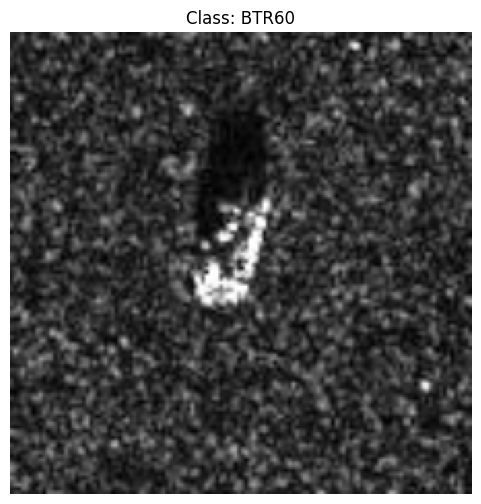

In [10]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

# Undo normalization for visualization
mean = torch.tensor([0.130710] * 3).view(3, 1, 1)
std = torch.tensor([0.125645] * 3).view(3, 1, 1)

image = images[0].cpu() * std + mean
image = image.clamp(0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Class: {classes[labels[0].item()]}")
plt.axis("off")
plt.show()

In [11]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using: cuda
GPU: Tesla T4


In [12]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

print("ResNet-18 loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


ResNet-18 loaded successfully!


In [13]:
import torch

model.fc = torch.nn.Linear(
    model.fc.in_features,
    len(classes)
)

print(model.fc)

Linear(in_features=512, out_features=11, bias=True)


In [14]:
model = model.to(device)

print("Model is using:", device)

Model is using: cuda


In [15]:
images, labels = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)

Input : torch.Size([32, 3, 224, 224])
Output: torch.Size([32, 11])


In [16]:
criterion = torch.nn.CrossEntropyLoss()


In [17]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.01
)

In [18]:
epochs = 10

In [19]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

print("Random seed:", seed)

Random seed: 42


In [20]:
for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Calculate training accuracy
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 0.8368 Accuracy: 70.51%
Epoch [2/10] Loss: 0.1516 Accuracy: 96.68%
Epoch [3/10] Loss: 0.0502 Accuracy: 99.11%
Epoch [4/10] Loss: 0.0266 Accuracy: 99.61%
Epoch [5/10] Loss: 0.0204 Accuracy: 99.74%
Epoch [6/10] Loss: 0.0166 Accuracy: 99.77%
Epoch [7/10] Loss: 0.0080 Accuracy: 99.97%
Epoch [8/10] Loss: 0.0262 Accuracy: 99.51%
Epoch [9/10] Loss: 0.0171 Accuracy: 99.74%
Epoch [10/10] Loss: 0.0113 Accuracy: 99.84%


In [21]:
torch.save(model.state_dict(), "resnet18_mstar.pth")

print("ResNet-18 model saved.")
# when sessuion restarts

ResNet-18 model saved.


In [22]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Clean Test Accuracy: {test_accuracy:.2f}%")

Clean Test Accuracy: 95.67%


In [23]:
all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

print("Predictions collected:", len(all_predictions))

Predictions collected: 2699


In [24]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes,
    digits=4
)

print(report)

              precision    recall  f1-score   support

         2S1     1.0000    0.9891    0.9945       274
        BMP2     0.6957    0.9846    0.8153       195
       BRDM2     0.9821    1.0000    0.9910       274
       BTR60     0.9200    0.9436    0.9316       195
       BTR70     1.0000    0.5051    0.6712       196
          D7     1.0000    1.0000    1.0000       274
       SLICY     1.0000    1.0000    1.0000       274
         T62     0.9963    0.9963    0.9963       273
         T72     0.9557    0.9898    0.9724       196
      ZIL131     1.0000    1.0000    1.0000       274
    ZSU_23_4     0.9928    1.0000    0.9964       274

    accuracy                         0.9567      2699
   macro avg     0.9584    0.9462    0.9426      2699
weighted avg     0.9661    0.9567    0.9536      2699



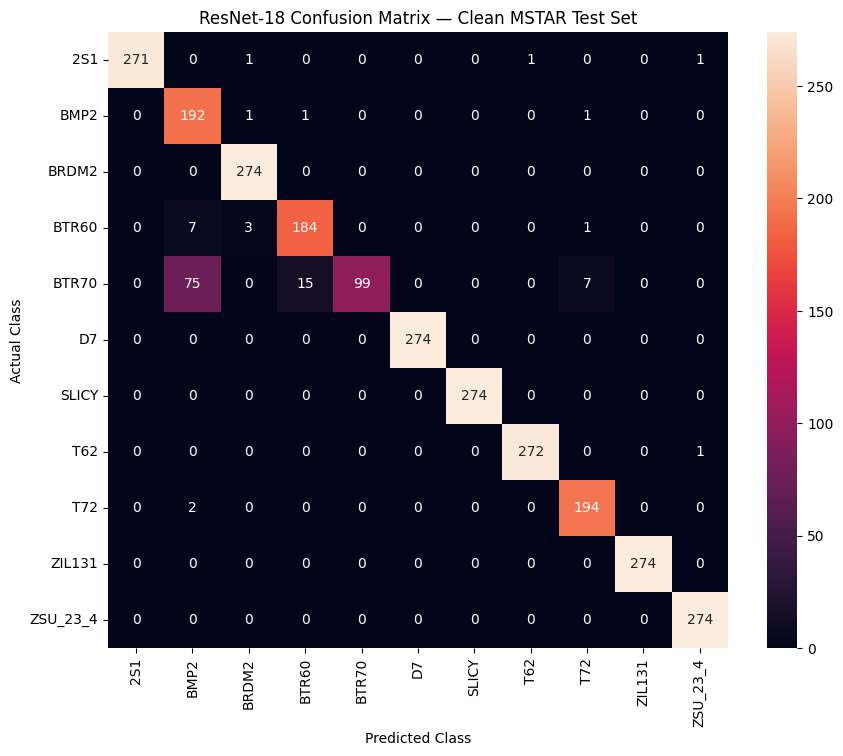

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("ResNet-18 Confusion Matrix — Clean MSTAR Test Set")
plt.show()